# EMU divergence vs abundance — does EMU call high-divergence species liberally?

**Hypothesis**: EMU calls species even when mapped reads show high divergence to reference sequences. savont, being more conservative, skips those calls.  

**Main plot**: per-species scatter of alignment divergence (x) vs EMU relative abundance (y), coloured by whether savont also calls that species.

> Prerequisites: run `emu_analysis.py` first to generate `emu_alignments_annotated.tsv` and `emu_species_summary.tsv`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## font size
plt.rcParams.update({'font.size': 7})

# ── Paths ──────────────────────────────────────────────────────────────────
# Run notebook from emu_analysis_real/ directory
HERE             = '.'

ANNOT_TSV        = f'{HERE}/emu_alignments_annotated.tsv'
EMU_ABUND        = f'{HERE}/cutadpt_all_rel-abundance.tsv'
SAVONT_ABUND     = f'{HERE}/species_abundance.tsv'

In [11]:
# ── Load annotated alignments (output of emu_analysis.py) ──────────────────
aln = pd.read_csv(ANNOT_TSV, sep='\t', dtype={'tax_id': str})
print(f'Alignments: {len(aln):,}  |  Reads: {aln.read_id.nunique():,}  |  Species: {aln.species.nunique()}')
aln.head(3)

Alignments: 9,298,403  |  Reads: 1,025,727  |  Species: 2907


,read_id,ref_name,tax_id,strain_id,species,AS,NM,de,mapq,is_primary,in_emu,delta_AS
0,8993e43d-3ead-4bdb-84ba-56488d4631d4,39485:emu_db:37551,39485,37551,Lachnospira eligens,2638,11,0.0081,6,True,True,0
1,8993e43d-3ead-4bdb-84ba-56488d4631d4,39485:emu_db:37550,39485,37550,Lachnospira eligens,2632,12,0.0088,0,False,True,6
2,8993e43d-3ead-4bdb-84ba-56488d4631d4,39485:emu_db:37552,39485,37552,Lachnospira eligens,2626,13,0.0096,0,False,True,12


In [12]:
# ── Load EMU abundance ─────────────────────────────────────────────────────
emu = pd.read_csv(EMU_ABUND, sep='\t', dtype={'tax_id': str})
emu['abundance'] = emu['abundance'].astype(float)
print(f'EMU species called: {len(emu)}')
emu.head(3)

EMU species called: 349


,tax_id,abundance,species,genus,family,order,class,phylum,clade,superkingdom,subspecies,species subgroup,species group,estimated counts
0,39485,0.025743,Lachnospira eligens,Lachnospira,Lachnospiraceae,Clostridiales,Clostridia,Firmicutes,Terrabacteria group,Bacteria,NaN,NaN,NaN,26397.172935
1,39491,0.038112,[Eubacterium] rectale,NaN,Lachnospiraceae,Clostridiales,Clostridia,Firmicutes,Terrabacteria group,Bacteria,NaN,NaN,NaN,39080.387218
2,2584943,0.005517,Longibaculum sp. KGMB06250,Longibaculum,Erysipelotrichaceae,Erysipelotrichales,Erysipelotrichia,Firmicutes,Terrabacteria group,Bacteria,NaN,NaN,NaN,5657.626416


In [13]:
# ── Load savont abundance ──────────────────────────────────────────────────
sav = pd.read_csv(SAVONT_ABUND, sep='\t', dtype={'tax_id': str})
sav['abundance'] = sav['abundance'].astype(float)
savont_species = set(sav['species'].dropna())
print(f'savont species called: {len(sav)}')
sav.head(3)

savont species called: 951


,tax_id,abundance,species,genus,family,order,class,phylum,clade,superkingdom
0,821,0.052556,Phocaeicola vulgatus,Phocaeicola,NaN,Bacteroidales,Bacteroidia,Bacteroidetes,FCB group,Bacteria
1,853,0.046682,Faecalibacterium prausnitzii,Faecalibacterium,Ruminococcaceae,Clostridiales,Clostridia,Firmicutes,Terrabacteria group,Bacteria
2,39491,0.034159,[Eubacterium] rectale,NaN,Lachnospiraceae,Clostridiales,Clostridia,Firmicutes,Terrabacteria group,Bacteria


In [14]:
# ── Per-species divergence stats from best-hit alignments ──────────────────
# Use only the best alignment per read (delta_AS == 0) to avoid inflating
# divergence with suboptimal secondary hits
best = aln[aln['delta_AS'] == 0].copy()

# For reads with ties, keep one row per read (already one per read at delta_AS==0
# for the primary, but in case of multi-tie take highest AS then first occurrence)
best = best.sort_values('AS', ascending=False).drop_duplicates('read_id')

div_stats = (
    best.groupby('tax_id')['de']
    .agg(
        n_reads='count',
        mean_de='mean',
        min_de=lambda x: x.min(),
        p5_de=lambda x: x.quantile(0.05),
        p50_de=lambda x: x.quantile(0.50),
        p95_de=lambda x: x.quantile(0.95),
    )
    .reset_index()
)
print(f'Species with divergence data: {len(div_stats)}')
div_stats.sort_values('mean_de', ascending=False).head()

Species with divergence data: 708


,tax_id,n_reads,mean_de,min_de,p5_de,p50_de,p95_de
10,1071054,1,0.2140,0.2140,0.2140,0.2140,0.2140
448,315358,1,0.2129,0.2129,0.2129,0.2129,0.2129
391,264639,1,0.2124,0.2124,0.2124,0.2124,0.2124
292,1938559,1,0.2090,0.2090,0.2090,0.2090,0.2090
120,1498,1,0.2083,0.2083,0.2083,0.2083,0.2083


In [15]:
# ── Build per-species comparison table ─────────────────────────────────────
emu_species_set = set(emu['species'].dropna())
print(f"EMU species: {len(emu_species_set)}")

cmp = (
    emu[['tax_id', 'abundance', 'species']]
    .merge(div_stats, on='tax_id', how='left')
)
print(f"EMU species with divergence data: {len(cmp.dropna(subset=['mean_de']))}")
cmp['category'] = cmp['species'].apply(
    lambda s: 'both' if s in savont_species else 'emu_only'
)

# ── Add savont-only rows (species savont calls but EMU does not) ────────────
savont_only_df = (
    sav.loc[~sav['species'].isin(emu_species_set) & ~sav['species'].str.contains('UNCLASSIFIED'), ['tax_id', 'species']]
    .assign(abundance=float('nan'))   # no EMU abundance
    .merge(div_stats, on='tax_id', how='left')
)
savont_only_df['category'] = 'savont_only'

cmp = pd.concat([cmp, savont_only_df], ignore_index=True)
cmp = cmp.dropna(subset=['mean_de'])

print(f"  both:        {(cmp['category']=='both').sum()}")
print(f"  emu_only:    {(cmp['category']=='emu_only').sum()}")
print(f"  savont_only: {(cmp['category']=='savont_only').sum()}")
cmp.sort_values('mean_de', ascending=False).head(6)

# print number of species in each category
print(f"  both:        {(cmp['category']=='both').sum()}")
print(f"  emu_only:    {(cmp['category']=='emu_only').sum()}")
print(f"  savont_only: {(cmp['category']=='savont_only').sum()}")


EMU species: 346
EMU species with divergence data: 336
  both:        114
  emu_only:    222
  savont_only: 1
  both:        114
  emu_only:    222
  savont_only: 1


                                           genus  abundance_savont  \
155                              Subdoligranulum          0.026967   
82                                      Gemmiger          0.002933   
49                                 Cuneatibacter          0.000000   
116                                   Monoglobus          0.001445   
29                                       Blautia          0.110081   
574  UNCLASSIFIED-(final_consensus_8_depth_7916)          0.008478   
39                               Christensenella          0.000000   
68                                   Eubacterium          0.006989   
101                                 Lacrimispora          0.003029   
123                                Oscillibacter          0.002455   

     abundance_emu  difference  
155       0.001293    0.010996  
82        0.027981   -0.010713  
49        0.021205   -0.009113  
116       0.017092   -0.006733  
29        0.121016   -0.004257  
574       0.000000    0.003666 

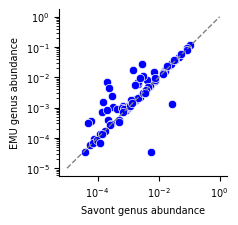

                                           species  abundance_savont  \
72                                    Blautia luti          0.000000   
157                   Faecalibacterium prausnitzii          0.046682   
1178                         [Eubacterium] siraeum          0.000000   
286                            Ruminococcus bromii          0.000000   
172                            Gemmiger formicilis          0.002657   
666   UNCLASSIFIED-(final_consensus_2_depth_22539)          0.024138   
124                       Cuneatibacter caecimuris          0.000000   
77                             Blautia sp. SC05B48          0.001195   
233                      Monoglobus pectinilyticus          0.001445   
229                           Megamonas funiformis          0.013551   

      abundance_emu  abundance_diff  
72         0.043285       -0.043285  
157        0.089918       -0.043236  
1178       0.037063       -0.037063  
286        0.033943       -0.033943  
172        0.0279

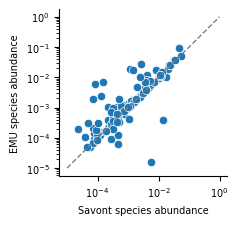

In [16]:
fig, ax = plt.subplots(1,1, figsize=(5.5/2.54, 5.5/2.54))
sav_genus_df = sav.groupby('genus')['abundance'].sum().reset_index()
emu_genus_df = emu.groupby('genus')['abundance'].sum().reset_index()
genus_df = pd.merge(sav_genus_df, emu_genus_df, on='genus', how='outer', suffixes=('_savont', '_emu')).fillna(0)
genus_df['difference'] = np.log10(genus_df['abundance_savont'] + 1) - np.log10(genus_df['abundance_emu'] + 1)
print(genus_df.sort_values('difference', key=abs, ascending=False).head(10))
sns.scatterplot(data=genus_df, x='abundance_savont', y='abundance_emu', label='savont', color='blue')
plt.plot([1e-5, 1], [1e-5, 1], color='gray', linestyle='--', linewidth=1.0, label='y=x')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Savont genus abundance')
plt.ylabel('EMU genus abundance')
sns.despine()
ax._remove_legend(True)
plt.savefig('genus_abundance_comparison_scatterplot.svg', bbox_inches='tight')
#print spearman correlation genus
spearman_corr_genus = genus_df[['abundance_savont', 'abundance_emu']].corr(method='pearson').iloc[0,1]

print(f"Pearson correlation between savont and EMU genus abundances: {spearman_corr_genus:.4f}")
plt.show()

fig, ax = plt.subplots(1,1, figsize=(5.5/2.54, 5.5/2.54))

abundance_df = pd.merge(sav[['species', 'abundance']], emu[['species', 'abundance']], on='species', how='outer', suffixes=('_savont', '_emu')
                        ).fillna(0)

sns.scatterplot(data=abundance_df, x='abundance_savont', y='abundance_emu')
plt.plot([1e-5, 1], [1e-5, 1], color='gray', linestyle='--', linewidth=1.0, label='y=x')
sns.despine()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel('EMU species abundance')
ax.set_xlabel('Savont species abundance')
# rank by difference
abundance_df['abundance_diff'] = abundance_df['abundance_savont'].fillna(0) - abundance_df['abundance_emu'].fillna(0)
abundance_df['abundance_diff_abs'] = abundance_df['abundance_diff'].abs()
abundance_df_sorted = abundance_df.sort_values('abundance_diff_abs', ascending=False)
ax._remove_legend(True)
plt.savefig('species_abundance_comparison_scatterplot.svg', bbox_inches='tight')
print(abundance_df_sorted[['species', 'abundance_savont', 'abundance_emu', 'abundance_diff']].head(10))

# print spearman correlation
spearman_corr = abundance_df[['abundance_savont', 'abundance_emu']].corr(method='pearson').iloc[0,1]
print(f"Pearson correlation between savont and EMU species abundances: {spearman_corr:.4f}")

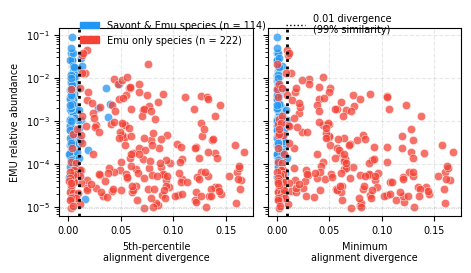

In [17]:
# ── Main scatter: divergence vs EMU abundance, coloured by category ─────────
fig, axes = plt.subplots(1, 2, figsize=(12/2.54, 6.5/2.54), sharey=True, sharex=True)


annotate = False
# savont-only has no EMU abundance — plot at the floor for visibility
floor = cmp['abundance'].dropna().min() / 3
cmp_plot = cmp.copy()
cmp_plot['abundance'] = cmp_plot['abundance'].fillna(floor)
cmp_plot = cmp_plot[~cmp_plot['species'].str.contains('UNCLASSIFIED')]

colors = {'both': '#2196F3', 'emu_only': '#F44336'}
labels = {'both': f'Savont & Emu species (n = {len(cmp_plot[cmp_plot["category"] == "both"])})', 
          'emu_only': f'Emu only species (n = {len(cmp_plot[cmp_plot["category"] == "emu_only"])})', 'savont_only': f'Savont only species (n = {len(cmp_plot[cmp_plot["category"] == "savont_only"])})'}

for ax, xcol, xlabel in zip(
    axes,
    ['p5_de', 'min_de'],
    ['5th-percentile\nalignment divergence', 'Minimum\nalignment divergence']
):
    for cat, grp in cmp_plot.groupby('category'):
        if cat == 'savont_only':
            continue
        ax.scatter(
            grp[xcol],
            grp['abundance'],
            c=colors[cat],
            label=labels[cat],
            alpha=0.75,
            edgecolors='white',
            linewidths=0.4,
        )

    # Label top-4 most abundant EMU-only species
    if annotate:
        for _, row in cmp_plot[cmp_plot['category'] == 'emu_only'].nlargest(4, 'abundance').iterrows():
            ax.annotate(
                row['species'] if isinstance(row['species'], str) else row['tax_id'],
                xy=(row[xcol], row['abundance']),
                fontsize=7, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points',
            )

            # Label top-4 most abundant EMU-only species
    for _, row in cmp_plot[cmp_plot['category'] == 'savont_only'].nlargest(4, 'abundance').iterrows():
        ax.annotate(
            row['species'] if isinstance(row['species'], str) else row['tax_id'],
            xy=(row[xcol], row['abundance']),
            fontsize=6, ha='left', va='bottom',
            xytext=(3, 3), textcoords='offset points',
        )

    ax.axhline(floor * 3, color='grey', linewidth=0.5, linestyle=':', alpha=0.6)
    ax.set_yscale('log')
    #ax.set_xscale('symlog')
    ax.set_xlabel(xlabel)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(0.01, color='black', linewidth=2.0, linestyle=':', alpha=1.0, label = '0.01 divergence\n(99% similarity)')

axes[0].set_ylabel('EMU relative abundance')
fig.legend(
    handles=[mpatches.Patch(color=colors[k], label=labels[k]) for k in colors] + [mlines.Line2D([0], [0], color='black', linewidth=1.0, linestyle=':', label='0.01 divergence\n(99% similarity)')],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=2,
    frameon=False,
)
plt.tight_layout()
plt.savefig(f'{HERE}/divergence_vs_abundance.svg', bbox_inches='tight')
plt.show()

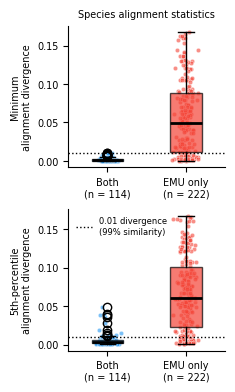

Mann-Whitney U (both < EMU-only): U=2240, p=0.0000
EMU-only species with min_de > 0.01: 188 / 222
Median min_de - both: 0.0037, EMU-only: 0.0608


In [18]:
# ── Bonus: violin/box of divergence distributions split by savont agreement ─
fig, axes = plt.subplots(2,1, figsize=(6/2.54, 10/2.54))


for stat in ['min_de', 'p5_de']:
    groups = [cmp.loc[cmp['category'] == 'both',  stat].dropna(),
              cmp.loc[cmp['category'] == 'emu_only', stat].dropna(),]
        #      cmp.loc[cmp['category'] == 'savont_only', stat].dropna()]
    ax = axes[0] if stat == 'min_de' else axes[1]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.4,
                medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#2196F3', '#F44336']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Overlay jittered points
    for i, (grp, color) in enumerate(zip(groups, ['#2196F3', '#F44336']), start=1):
        ax.scatter(
            np.random.normal(i, 0.06, size=len(grp)),
            grp, alpha=0.6, s=10, color=color, edgecolors='white', linewidths=0.4
        )

    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'Both\n(n = {len(groups[0])})', f'EMU only\n(n = {len(groups[1])})'])
                   #     f'Savont only\n(n = {len(groups[2])})'])
    ax.set_ylabel(f'{"Minimum" if stat=="min_de" else "5th-percentile"}\nalignment divergence')
    ax.axhline(0.01, color='black', linewidth=1.0, linestyle=':', alpha=1.0, label = '0.01 divergence\n(99% similarity)')
    if stat == 'min_de':
        ax.set_title('Species alignment statistics', fontsize=7)
    plt.legend(frameon=False, fontsize=6)
    sns.despine()
    #ax.set_title('Is EMU-only species associated with higher divergence?')
    #ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()

plt.savefig(f'{HERE}/divergence_boxplot.pdf', bbox_inches='tight')
plt.show()

# Quick Mann-Whitney test
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(groups[0], groups[1], alternative='less')
print(f'Mann-Whitney U (both < EMU-only): U={stat:.0f}, p={p:.4f}')
# number emu only > 0.01 min_de
print(f'EMU-only species with min_de > 0.01: {(groups[1] > 0.01).sum()} / {len(groups[1])}')

#print median
print(f'Median min_de - both: {np.median(groups[0]):.4f}, EMU-only: {np.median(groups[1]):.4f}')

In [19]:
# ── Table: EMU-only species sorted by divergence (the 'liberal' calls) ─────
emu_only = (
    cmp[~cmp['in_savont']]
    [['species', 'tax_id', 'abundance', 'n_reads', 'mean_de', 'p95_de']]
    .sort_values('mean_de', ascending=False)
    .reset_index(drop=True)
)
print(f'EMU-only species: {len(emu_only)}')
emu_only

KeyError: 'in_savont'